# Context specificity vs. number of PCs — cosine distance to batch-matched DMSO

**New definition (from `18_PerturbationManifoldMotion.ipynb`).** For a genetic perturbation (gene) *g* in a
drug context *d*, its context specificity in that context is the **cosine distance** between the
perturbation's signature `d::g` and the **same perturbation in the batch-matched DMSO context**
(`DMSO_of_batch(d)::g`). The perturbation's overall **context specificity = mean of these cosine distances
across all (non-DMSO) drug contexts** (notebook 18 calls this per-gene "motion").

Batch matching (Round-2 design, mirrored from notebook 18):
`batch1 → DMSO_round2`, `batch2 → DMSO_round2_batch2`.

Here we recompute this score while sweeping the number of PCs used (up to **500**), and report:
1. **Explained variance of the whole matrix vs # PCs.**
2. **Distribution of the per-gene context-specificity score vs # PCs** (one value per genetic perturbation).
3. **UMAPs coloured by drug** for several PC counts.

We reuse the scaled matrix in `perturbation_embeddings.h5ad` and recompute PCA with 500 components; each PC
setting uses the first *k* PCs (`X_pca[:, :k]`) for the cosine distances — matching notebook 18's
`X = adata.obsm['X_pca'][:, :N_PCS]`.

In [19]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt

# ---- Parameters ---------------------------------------------------------
projectDir = "/home/beraslan/Projects/ChemoGeneticScreens"
EMB_H5  = os.path.join(projectDir, "PerturbationEmbeddings", "perturbation_embeddings.h5ad")
OUT_DIR = os.path.join(projectDir, "PerturbationEmbeddings", "pc_sweep")
os.makedirs(OUT_DIR, exist_ok=True)

MAX_PCS  = 500                                                  # upper bound on PCs
MIN_DRUGS = 3                                                   # gene must be tested in >= this many non-DMSO drugs (matches nb18)
SPEC_PCS = [2, 5, 10, 25, 50, 75, 100, 150, 200, 250, 300, 400, 500]   # PCs for variance + context-spec sweep
UMAP_PCS = [2, 5, 10, 25, 50, 75, 100, 150, 200, 250, 300, 400, 500]                        # PCs for UMAP panels
N_NEIGHBORS = 15                                                # for the UMAP graph only

# Batch -> DMSO mapping (mirrored from notebook 18 / SampleSheet, Round2)
BATCH_DRUGS = {
    "batch1": ["AR-A014418", "AZD4573", "CHIR-98014", "Lexibulin", "PP121",
               "Romidepsin", "Stattic", "DMSO_round2"],
    "batch2": ["Bisindolylmaleimide-I", "DG-172", "JTE-607", "LDN-193189",
               "LY2090314", "NSC95397", "VX-11e", "DMSO_round2_batch2"],
}
DMSO_OF_BATCH = {"batch1": "DMSO_round2", "batch2": "DMSO_round2_batch2"}
DMSO_DRUGS    = set(DMSO_OF_BATCH.values())
BATCH_OF_DRUG = {d: b for b, ds in BATCH_DRUGS.items() for d in ds}

In [9]:
# ---- Load scaled matrix, recompute PCA with MAX_PCS, set up batch arrays
adata = sc.read_h5ad(EMB_H5)
if not sp.issparse(adata.X):
    adata.X = np.asarray(adata.X, dtype=np.float32)

split = adata.obs_names.to_series().str.split("::", expand=True)
adata.obs["drug"] = [s.replace("PosteriorMean_matrix_", "") for s in split[0]]
adata.obs["gene"] = split[1].values

genes = adata.obs["gene"].to_numpy()
drugs = adata.obs["drug"].to_numpy()
unknown = sorted(set(np.unique(drugs)) - set(BATCH_OF_DRUG))
assert not unknown, f"Drugs missing batch mapping: {unknown}"
is_dmso   = np.isin(drugs, list(DMSO_DRUGS))
batch_arr = np.array([BATCH_OF_DRUG[d] for d in drugs])

print("matrix:", adata.shape, "| drugs:", sorted(np.unique(drugs)))
sc.tl.pca(adata, n_comps=MAX_PCS)
print("PCA done:", adata.obsm["X_pca"].shape)

# Precompute, for each row, the index of its gene's batch-matched DMSO row (k-independent)
dmso_idx = {}
for i in np.where(is_dmso)[0]:
    dmso_idx[(genes[i], batch_arr[i])] = i
base_idx = np.array([dmso_idx.get((genes[i], batch_arr[i]), -1) for i in range(adata.n_obs)])
print("rows with a batch-matched DMSO baseline:", int((base_idx >= 0).sum()), "/", adata.n_obs)

matrix: (30704, 14639) | drugs: ['AR-A014418', 'AZD4573', 'Bisindolylmaleimide-I', 'CHIR-98014', 'DG-172', 'DMSO_round2', 'DMSO_round2_batch2', 'JTE-607', 'LDN-193189', 'LY2090314', 'Lexibulin', 'NSC95397', 'PP121', 'Romidepsin', 'Stattic', 'VX-11e']
PCA done: (30704, 500)
rows with a batch-matched DMSO baseline: 30704 / 30704


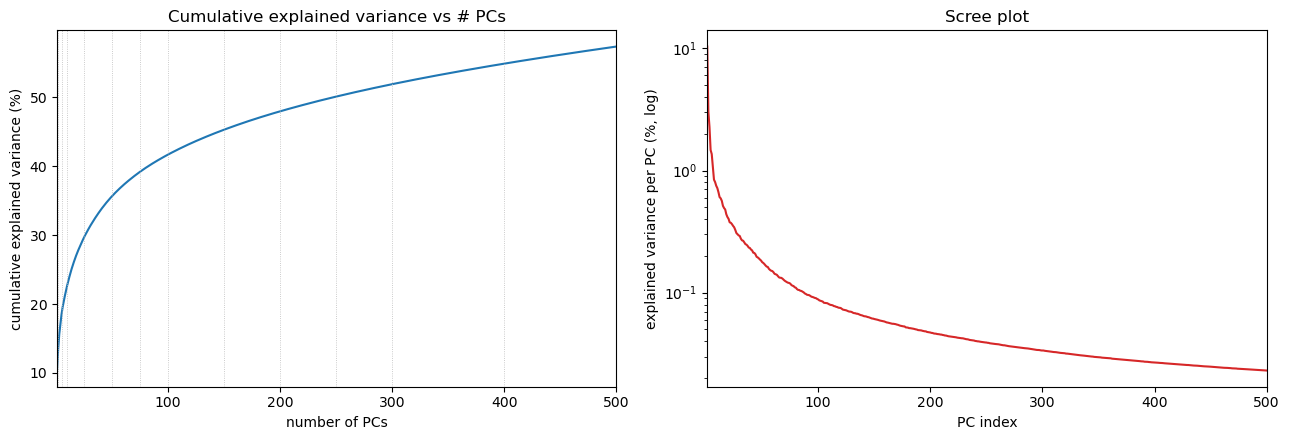

    2 PCs ->  13.4% variance
    5 PCs ->  18.5% variance
   10 PCs ->  22.7% variance
   25 PCs ->  29.6% variance
   50 PCs ->  35.6% variance
   75 PCs ->  39.2% variance
  100 PCs ->  41.7% variance
  150 PCs ->  45.3% variance
  200 PCs ->  48.0% variance
  250 PCs ->  50.1% variance
  300 PCs ->  51.9% variance
  400 PCs ->  54.9% variance
  500 PCs ->  57.4% variance


In [10]:
# ===== Plot 1: explained variance of the whole matrix vs # PCs ==========
vr = adata.uns["pca"]["variance_ratio"]
cum = np.cumsum(vr) * 100.0
pcs = np.arange(1, len(vr) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(pcs, cum, color="#1f77b4")
for k in SPEC_PCS: axes[0].axvline(k, color="#bbb", lw=0.6, ls=":")
axes[0].set_xlabel("number of PCs"); axes[0].set_ylabel("cumulative explained variance (%)")
axes[0].set_title("Cumulative explained variance vs # PCs"); axes[0].set_xlim(1, MAX_PCS)
axes[1].plot(pcs, vr * 100.0, color="#d62728"); axes[1].set_yscale("log")
axes[1].set_xlabel("PC index"); axes[1].set_ylabel("explained variance per PC (%, log)")
axes[1].set_title("Scree plot"); axes[1].set_xlim(1, MAX_PCS)
plt.tight_layout(); plt.savefig(os.path.join(OUT_DIR, "explained_variance_vs_pcs.png"), dpi=150)
plt.show()
for k in SPEC_PCS: print(f"  {k:>3d} PCs -> {cum[k-1]:5.1f}% variance")

In [11]:
# ---- helper: per-gene context specificity = mean cosine distance to ----
# the gene's batch-matched DMSO baseline, using the first n_pcs PCs (nb18 logic)
def context_specificity_motion(adata, n_pcs):
    X = adata.obsm["X_pca"][:, :n_pcs]
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True).clip(min=1e-12)  # unit rows
    row_cos = np.full(adata.n_obs, np.nan)
    valid = (base_idx >= 0) & ~is_dmso                                 # non-DMSO rows w/ a baseline
    row_cos[valid] = 1.0 - np.sum(Xn[valid] * Xn[base_idx[valid]], axis=1)
    # per-gene mean over its non-DMSO drug rows (require >= MIN_DRUGS)
    s = pd.Series(row_cos[valid], index=genes[valid])
    grp = s.groupby(level=0)
    motion = grp.mean()
    motion = motion[grp.count() >= MIN_DRUGS]
    return motion

In [12]:
# ===== Sweep: per-gene context specificity (motion) vs # PCs ===========
spec_by_pc = {}
summary = []
for k in SPEC_PCS:
    m = context_specificity_motion(adata, k)
    spec_by_pc[k] = m
    v = m.to_numpy()
    summary.append({"n_pcs": k, "n_genes": len(v), "median": np.median(v), "mean": v.mean(),
                    "q25": np.percentile(v, 25), "q75": np.percentile(v, 75)})
    print(f"  n_pcs={k:>3d}: genes={len(v):>4d}  median cos-dist={np.median(v):.3f}  mean={v.mean():.3f}")

summary = pd.DataFrame(summary)
pd.DataFrame({k: spec_by_pc[k] for k in SPEC_PCS}).rename_axis("gene").to_csv(
    os.path.join(OUT_DIR, "context_specificity_motion_by_npcs_pergene.csv"))
summary.to_csv(os.path.join(OUT_DIR, "context_specificity_motion_summary_by_npcs.csv"), index=False)
summary.round(3)

  n_pcs=  2: genes=1919  median cos-dist=0.010  mean=0.124
  n_pcs=  5: genes=1919  median cos-dist=0.053  mean=0.140
  n_pcs= 10: genes=1919  median cos-dist=0.101  mean=0.173
  n_pcs= 25: genes=1919  median cos-dist=0.150  mean=0.202
  n_pcs= 50: genes=1919  median cos-dist=0.195  mean=0.235
  n_pcs= 75: genes=1919  median cos-dist=0.224  mean=0.259
  n_pcs=100: genes=1919  median cos-dist=0.248  mean=0.277
  n_pcs=150: genes=1919  median cos-dist=0.283  mean=0.303
  n_pcs=200: genes=1919  median cos-dist=0.332  mean=0.340
  n_pcs=250: genes=1919  median cos-dist=0.370  mean=0.370
  n_pcs=300: genes=1919  median cos-dist=0.381  mean=0.378
  n_pcs=400: genes=1919  median cos-dist=0.394  mean=0.386
  n_pcs=500: genes=1919  median cos-dist=0.402  mean=0.392


,n_pcs,n_genes,median,mean,q25,q75
0,2,1919,0.010,0.124,0.003,0.146
1,5,1919,0.053,0.140,0.024,0.185
2,10,1919,0.101,0.173,0.062,0.226
3,25,1919,0.150,0.202,0.102,0.262
4,50,1919,0.195,0.235,0.145,0.291
5,75,1919,0.224,0.259,0.175,0.318
6,100,1919,0.248,0.277,0.196,0.335
7,150,1919,0.283,0.303,0.228,0.363
8,200,1919,0.332,0.340,0.267,0.399
9,250,1919,0.370,0.370,0.303,0.433


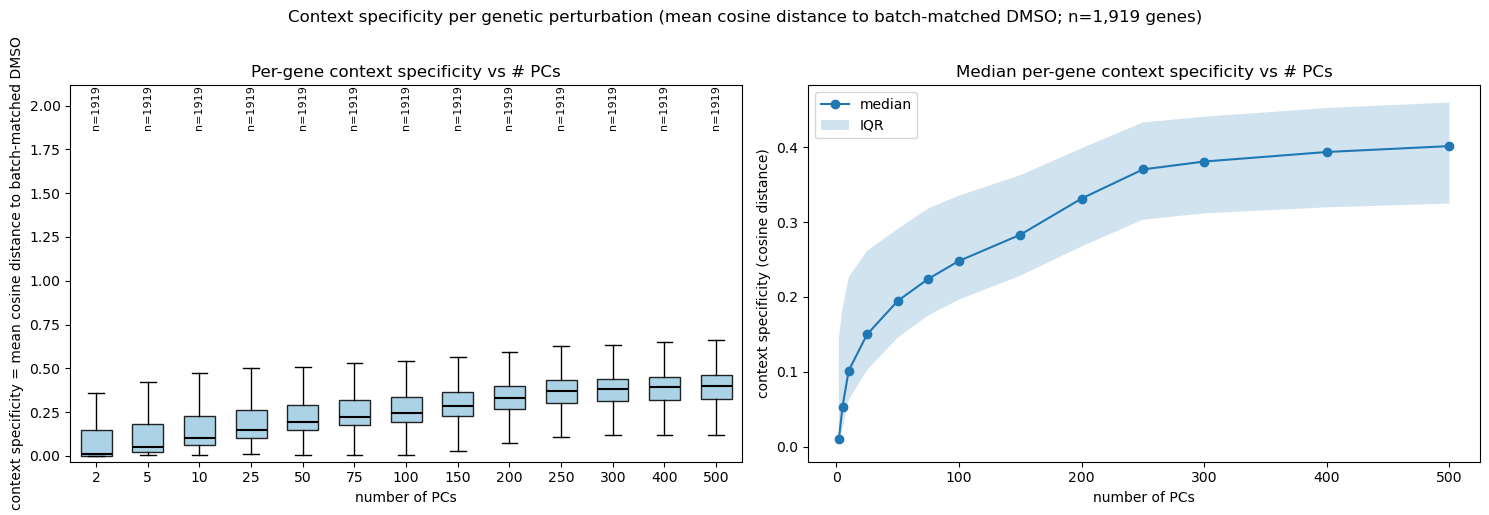

In [13]:
# ===== Plot 2: per-gene context specificity (cosine-to-DMSO) vs # PCs ===
try:
    spec_by_pc; summary
except NameError:
    _df = pd.read_csv(os.path.join(OUT_DIR, "context_specificity_motion_by_npcs_pergene.csv"), index_col=0)
    spec_by_pc = {int(c): _df[c] for c in _df.columns}
    summary = pd.read_csv(os.path.join(OUT_DIR, "context_specificity_motion_summary_by_npcs.csv"))

data   = [np.asarray(pd.Series(spec_by_pc[k]).dropna()) for k in SPEC_PCS]
counts = [len(d) for d in data]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
bp = axes[0].boxplot(data, positions=range(len(SPEC_PCS)), widths=0.6,
                     showfliers=False, patch_artist=True,
                     medianprops=dict(color="black", lw=1.5))
for patch in bp["boxes"]:
    patch.set_facecolor("#9ecae1"); patch.set_alpha(0.85)
axes[0].set_xticks(range(len(SPEC_PCS))); axes[0].set_xticklabels(SPEC_PCS)
axes[0].set_xlabel("number of PCs")
axes[0].set_ylabel("context specificity = mean cosine distance to batch-matched DMSO")
axes[0].set_title("Per-gene context specificity vs # PCs")
ymax = max(d.max() for d in data)
for i, nperts in enumerate(counts):
    axes[0].text(i, ymax * 1.01, f"n={nperts}", ha="center", va="bottom", fontsize=8, rotation=90)
axes[0].set_ylim(top=ymax * 1.15)

axes[1].plot(summary["n_pcs"], summary["median"], "o-", label="median")
axes[1].fill_between(summary["n_pcs"], summary["q25"], summary["q75"], alpha=0.2, label="IQR")
axes[1].set_xlabel("number of PCs"); axes[1].set_ylabel("context specificity (cosine distance)")
axes[1].set_title("Median per-gene context specificity vs # PCs"); axes[1].legend()

fig.suptitle(f"Context specificity per genetic perturbation "
             f"(mean cosine distance to batch-matched DMSO; n={counts[0]:,} genes)", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "context_specificity_motion_vs_pcs.png"), dpi=150, bbox_inches="tight")
plt.show()

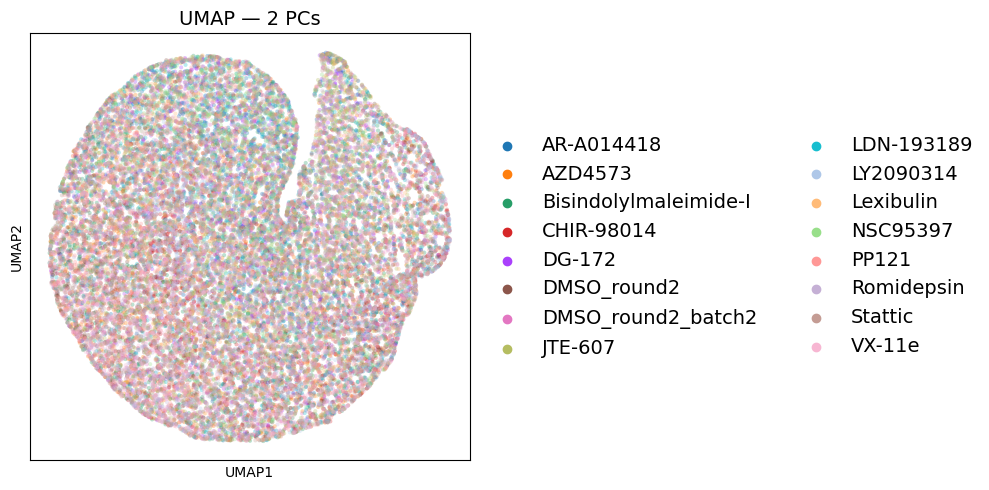

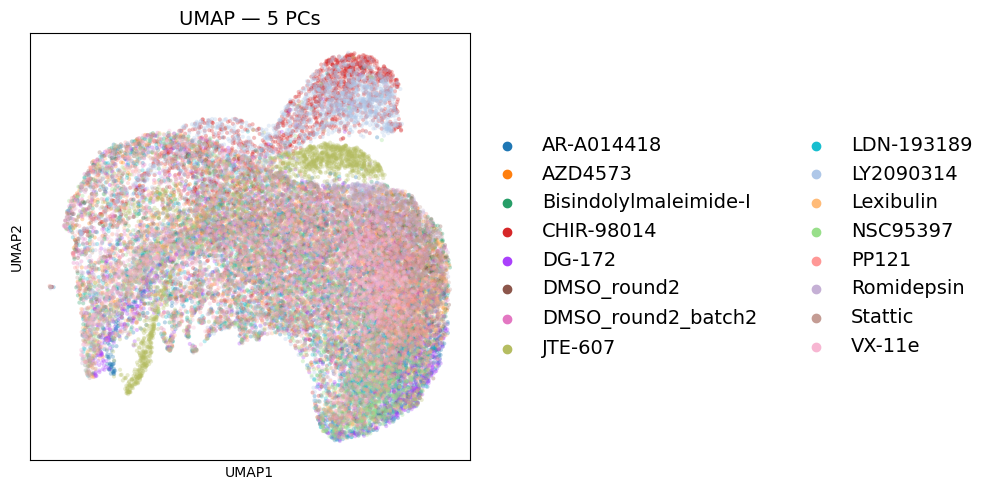

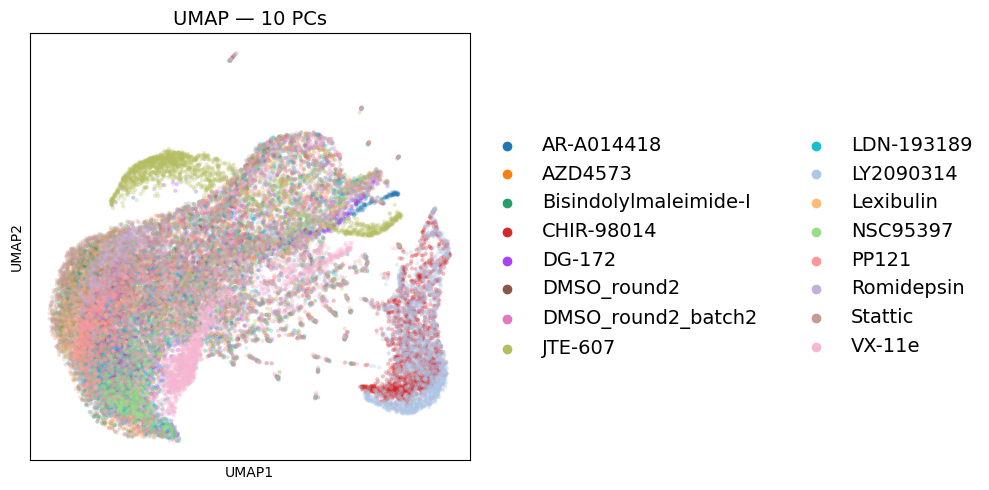

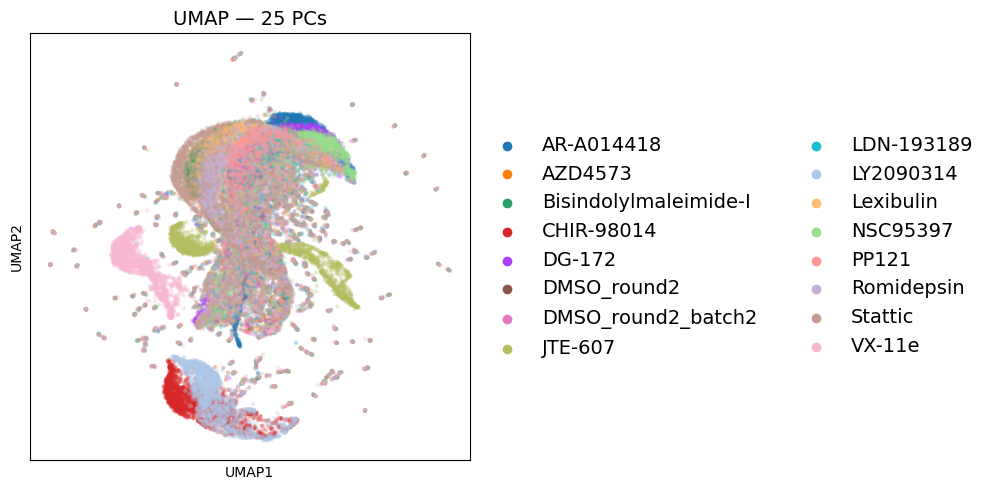

/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


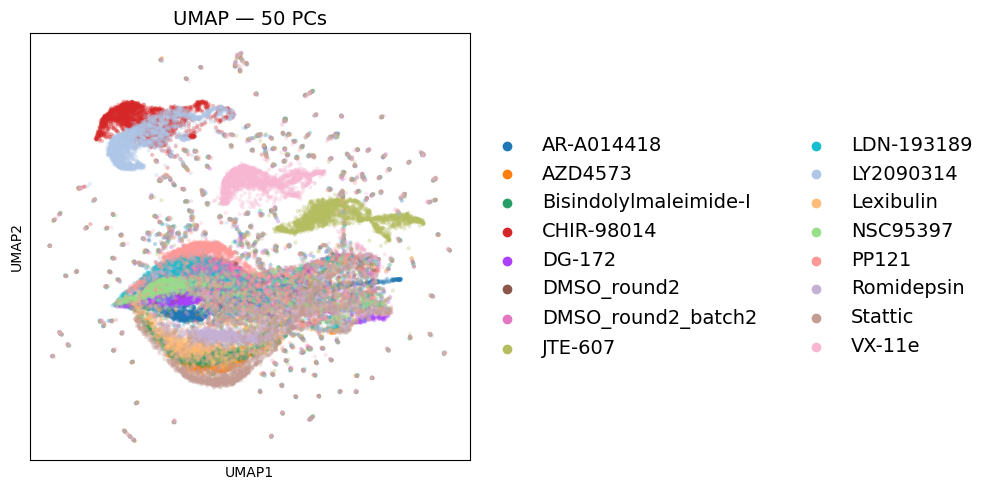

/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


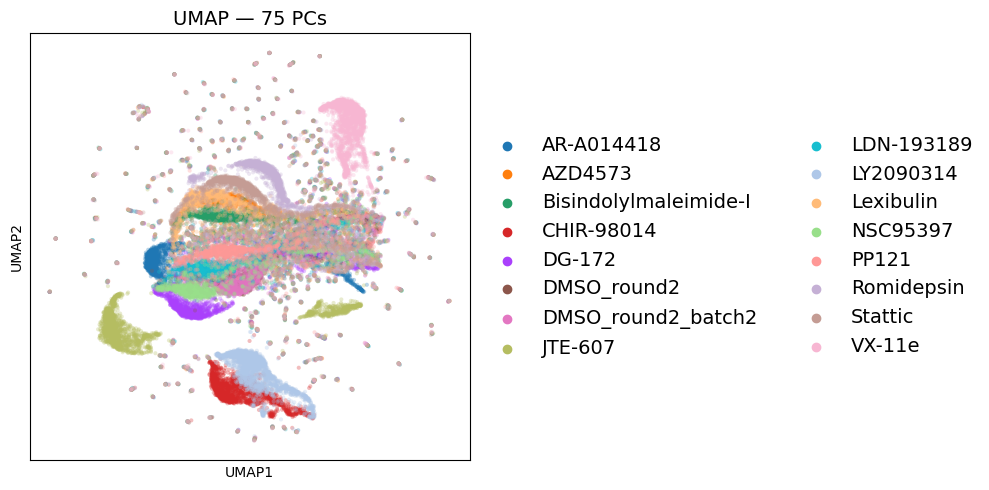

/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


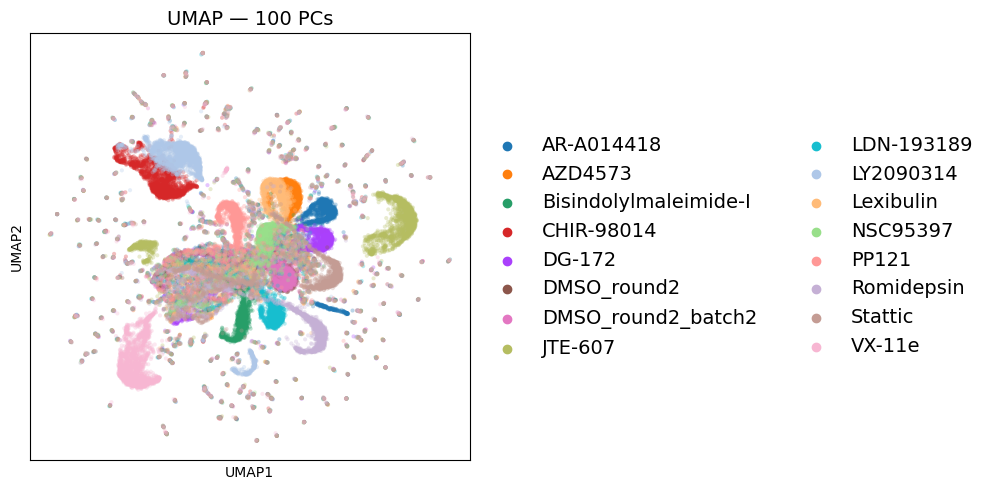

/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


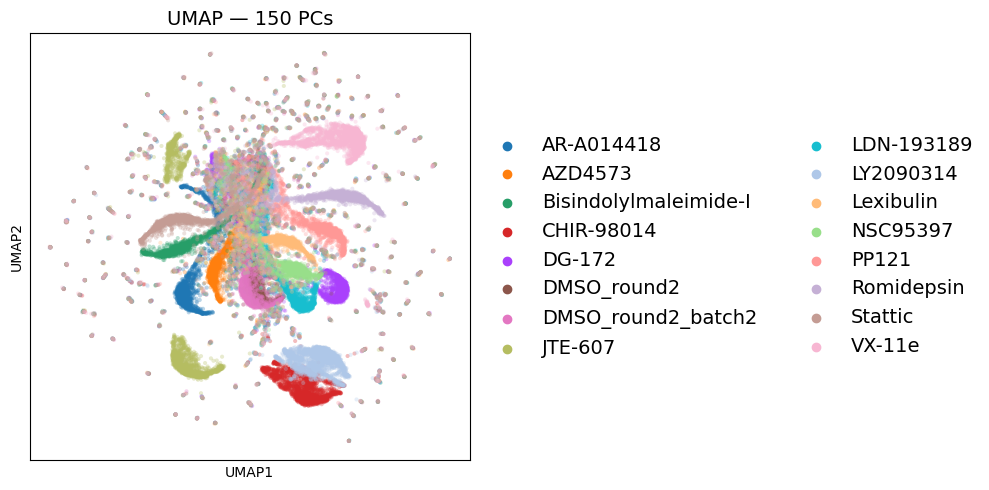

/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


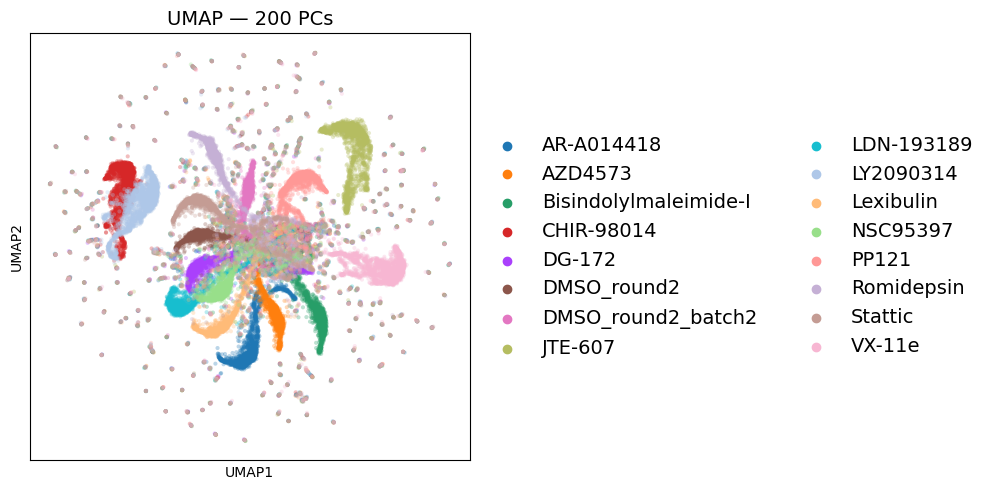

/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


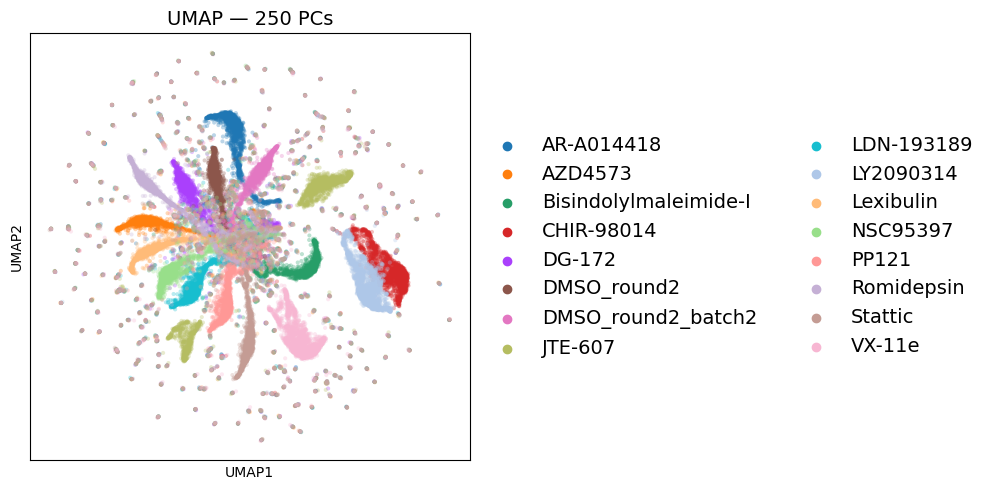

/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


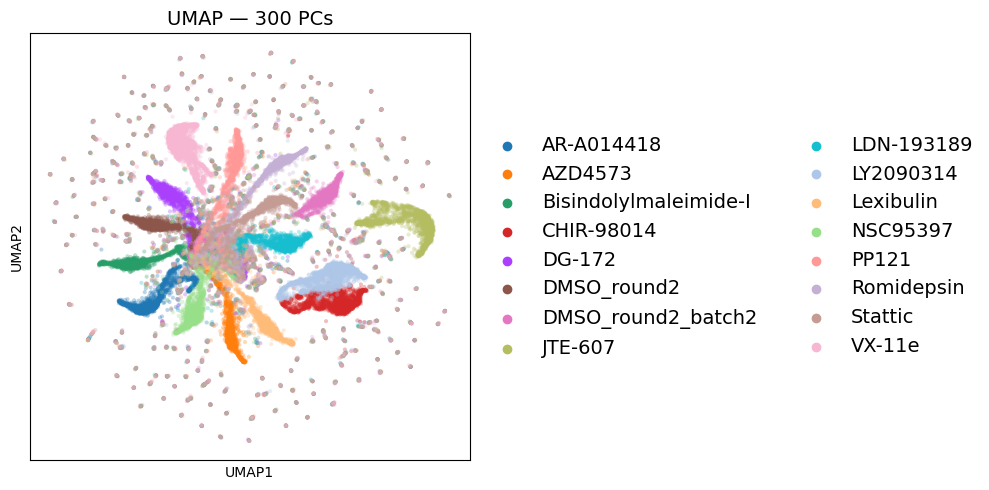

/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


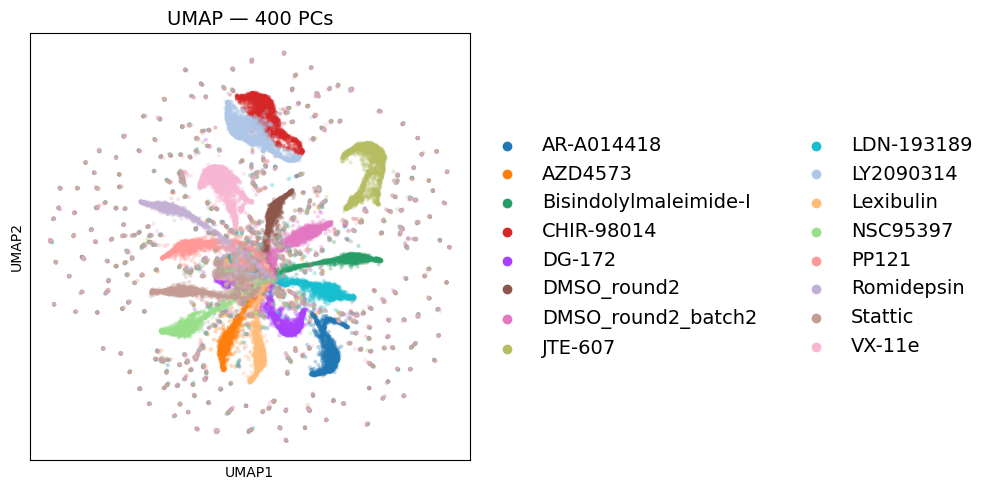

/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


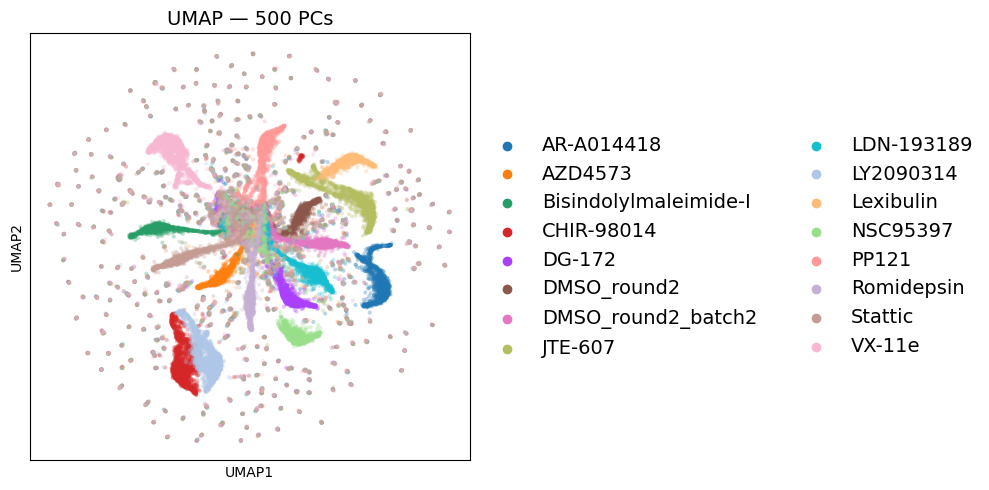

In [20]:
# ===== Plot 3: UMAP coloured by drug — a SEPARATE figure per # PCs =====
for k in UMAP_PCS:
    sc.pp.neighbors(adata, n_neighbors=N_NEIGHBORS, use_rep="X_pca", n_pcs=k)
    sc.tl.umap(adata)
    fig, ax = plt.subplots(figsize=(10,5))
    sc.pl.umap(adata, color='drug', size=35, alpha=0.3, legend_fontoutline=3,
               legend_fontsize=14, ax=ax, legend_fontweight='normal', show=False)
    ax.set_title(f"UMAP — {k} PCs", fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, f"umap_by_drug_{k}PCs.png"), dpi=150)
    plt.show()

## Notes & outputs

- **Context specificity definition (this notebook):** per gene, the **mean cosine distance** between each
  `(drug, gene)` signature and the **same gene's batch-matched DMSO** signature, over non-DMSO drug
  contexts — i.e. notebook 18's per-gene "motion", computed in the first *k* PCs.
- **One value per genetic perturbation:** genes are required to be tested in ≥ `MIN_DRUGS` non-DMSO drugs;
  `n` (annotated on each box) is therefore constant across PC counts.
- **Outputs** (`PerturbationEmbeddings/pc_sweep/`): `explained_variance_vs_pcs.png`,
  `context_specificity_motion_vs_pcs.png`, `umap_by_drug_<k>PCs.png` (one per PC count),
  `context_specificity_motion_by_npcs_pergene.csv`, `context_specificity_motion_summary_by_npcs.csv`.
- Matches notebook 18 at `n_pcs=250` (its `N_PCS`), so this sweep generalises that single setting.